## Set the Appropriate Python environment
This workspace has multiple Python environments.
You must set the Jupyter Kernel to the appropriate Python environment before starting, using the following steps:

* Click on the **Select Kernel** button.
* Use **Jupyter Kernel** as the Python source. 
* Select Python **(venv2)**

# Project: Teaching an LLM to Reason

**Author:** Dennis O'Higgins

In this project, you will teach an LLM to use step-by-step reasoning to answer the question: "How many X's are there in the word Y?"

Counting letters in a word is a surprisingly complex task for an LLM. Just as human beings would not be able to answer such a question for longer words without breaking down the word into its individual letters and then counting them, LLMs cannot be similarly expected to be able to respond without using smaller reasoning steps.

For example, to count the number of o's in the word room, one could use the following reasoning:

```
Question: How many of the letter "o" are there in the word "room"
Answer: 2
Response:

<reasoning>
Letter-by-letter spelling:
1. r - 0 o's so far
2. o - 1 o's so far
3. o - 2 o's so far
4. m - 2 o's so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
```

In this project we will use the reinforcement learning method GRPO (Group Relative Policy Optimization, of DeepSeek fame) to take a large language model that has been fine-tuned for following instructions and teach it how to break a word down into its letters and then count the requested letter.

We will complete the following steps:

* Set up the notebook
* Create a letter-counting dataset
* Create the reward functions
* Train the model
* View the results

NOTE: This notebook will have you focus on several important aspects of training a GPRO model using LoRA:

1. Configuring LoRA adapters for parameter-efficient fine tuning
2. Selecting reward functions that help the model efficiently find its way to the correct answer (also called reward shaping)
3. Finding hyperparameters that help the model increase the rewards earned more quickly and reliably
4. Learning how to start with smaller experiments and to work your way up to longer experiments.

## Set up the notebook

We'll install dependencies needed for the project, namely `unsloth` and `vllm`, which are useful for fine-tuning LLMs with even just 15GB of VRAM.

**Environment used for this run:** Google Colab with an NVIDIA T4 GPU (16 GB), using a Python 3.12 virtual environment built from the project's pinned `requirements.txt` (installed with `--no-deps`, as described in the project's environment Option 2).

In [1]:
# Load ipython-autotime to see how long each cell take to run
# No changes needed in this cell

!pip install -q ipython-autotime
%load_ext autotime

time: 177 μs (started: 2026-10-07 10:27:30 +00:00)


In [2]:
# Verify we have enough GPU memory to run this project (at least 15360MiB)
# No changes needed in this cell

!nvidia-smi

Wed Oct  7 10:27:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

time: 435 ms (started: 2026-10-07 10:27:30 +00:00)


In [3]:
# Load the `Qwen 2.5 3B Instruct`, and set parameters for the project
# The first time unsloth is imported, it will do its magic and patch the modules
# it works with. This may 2-5 minutes.

import unsloth

from unsloth import FastLanguageModel
import torch

max_seq_length = 384  # Increase if you get errors about the sequence length

# Set the LoRA rank to an appropriate value
# Read about setting LoRA rank:
# https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
# I use a rank of 64. Letter-by-letter spelling with a running count is a new,
# fairly structured behaviour, so the adapter needs enough capacity to learn it
# quickly, but the task is narrow, so a very large rank (128) would mostly add
# memory use and the risk of overfitting on a T4. Rank 64 is the starting point
# recommended in the Unsloth guide and keeps the trainable parameters to a small
# fraction of the 3B model. lora_alpha is set equal to the rank below, giving a
# scaling factor (alpha / r) of 1, so the adapter updates are neither damped nor
# amplified.
lora_rank = 64

# Load the Instruct model in 4-bit mode
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-3B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,  # We'll use quantization!
    fast_inference=True,  # This uses vllm for faster inference
    max_lora_rank=lora_rank,
    gpu_memory_utilization=0.5,  # You can reduce this if you get an memory error
)

model = FastLanguageModel.get_peft_model(
    model,
    r=lora_rank,
    target_modules=[
        # Read about choosing adapters for LoRA:
        # https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
        # Choose the target modules/adapters for your LoRA model
        # I target every linear projection in each transformer block, as the Unsloth
        # guide recommends for best quality. The attention projections (q, k, v, o)
        # control which earlier tokens the model attends to, which matters when it
        # tracks the current letter and the running total. The MLP projections
        # (gate, up, down) hold most of the model's transformation capacity and help
        # it learn the new step-by-step output pattern. Adapting only attention
        # usually learns more slowly and less reliably for a new reasoning format.
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_alpha=lora_rank,
    use_gradient_checkpointing="unsloth",  # Unsloth enables longer contexts
    # See: https://github.com/unslothai/unsloth
)

/content/g312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


INFO 10-07 10:28:20 [__init__.py:241] Automatically detected platform cuda.


ERROR 10-07 10:28:23 [fa_utils.py:57] Cannot use FA version 2 is not supported due to FA2 is only supported on devices with compute capability >= 8


🦥 Unsloth Zoo will now patch everything to make training faster!


...

INFO 10-07 10:30:05 [llm.py:298] Supported_tasks: ['generate']


Unsloth: Just some info: will skip parsing ['layer_norm2', 'post_layernorm', 'layer_norm1', 'post_attention_layernorm', 'k_norm', 'norm1', 'q_norm', 'pre_feedforward_layernorm', 'norm2', 'input_layernorm', 'post_feedforward_layernorm']


Unsloth: Just some info: will skip parsing ['layer_norm2', 'post_layernorm', 'layer_norm1', 'post_attention_layernorm', 'k_norm', 'norm1', 'cross_attn_input_layernorm', 'cross_attn_post_attention_layernorm', 'q_norm', 'pre_feedforward_layernorm', 'norm2', 'input_layernorm', 'post_feedforward_layernorm']


Unsloth 2025.9.7 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


time: 2min 50s (started: 2026-10-07 10:27:31 +00:00)


## Try Prompt Engineering to Count Letters

Let's work on the system prompt a little to see if we can get the model to count the number of the letter `g` in `engage`.


Here you must:
* Write clear instructions
* Break the problem down into steps (Chain-of-Thought prompting)
* Provide at least one example for the model to follow (Few-shot prompting)

In [4]:
# First, let's see what happens when we have a blank system prompt
# No changes needed in this cell
SYSTEM_PROMPT = """"""
USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests: 100%|██████████| 1/1 [00:00<00:00, 335.28it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:09<00:00,  9.18s/it, est. speed input: 3.16 toks/s, output: 1.63 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:09<00:00,  9.18s/it, est. speed input: 3.16 toks/s, output: 1.63 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:09<00:00,  9.19s/it, est. speed input: 3.16 toks/s, output: 1.63 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in the word "engage"<|im_end|>
<|im_start|>assistant

=== GENERATED OUTPUT ===
In the word "engage", there is only one letter "g".
time: 9.21 s (started: 2026-10-07 10:30:21 +00:00)


Without any prompting the model will generate an output such as this:

```
=== GENERATED OUTPUT ===
There is one letter "g" in the word "engage".
```

Now let's work on the system prompt to help the model break this problem down into steps, which might help it get the right answer (2 `g`'s in `engage`)

In [5]:
# Let's work on a new system prompt that will help the model break this problem
# down into steps, for example, using "letter-by-letter" spelling.

# Use a CoT prompt with at least one example
SYSTEM_PROMPT = """You count how many times a letter appears in a word.
Do not guess. Think step by step:
1. Spell the word one letter at a time, numbering each letter.
2. At each letter, check whether it is the letter you were asked to count.
3. Keep a running total of the requested letter after every step.
4. After the last letter, state the final total.

Always answer in exactly this format:
<reasoning>
Counting the number of [letter]'s in the word [word]
1. [first letter] - [running total] so far
2. [second letter] - [running total] so far
...
</reasoning>
<answer>
[final total as a number]
</answer>

Example:
Question: How many of the letter "o" are there in the word "room"
Response:
<reasoning>
Counting the number of o's in the word room
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
"""


USER_PROMPT = 'How many of the letter "g" are there in the word "engage"'

# Convert the chat messages to a single string so the model can complete it
text_for_completion = tokenizer.apply_chat_template(
    conversation=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": USER_PROMPT,
        },
    ],
    tokenize=False,
    add_generation_prompt=True,
)

from vllm import SamplingParams

# Set the LLM sampling parameters
sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=2048,
)

# Generate the text completion
output = (
    model.fast_generate(
        [text_for_completion],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

# Print the text input for the model and the model's output
print("=== TEXT FOR COMPLETION ===")
print(text_for_completion)
print("=== GENERATED OUTPUT ===")
print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests: 100%|██████████| 1/1 [00:00<00:00, 283.72it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it, est. speed input: 103.57 toks/s, output: 37.46 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it, est. speed input: 103.57 toks/s, output: 37.46 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.73s/it, est. speed input: 103.57 toks/s, output: 37.46 toks/s]

=== TEXT FOR COMPLETION ===
<|im_start|>system
You count how many times a letter appears in a word.
Do not guess. Think step by step:
1. Spell the word one letter at a time, numbering each letter.
2. At each letter, check whether it is the letter you were asked to count.
3. Keep a running total of the requested letter after every step.
4. After the last letter, state the final total.

Always answer in exactly this format:
<reasoning>
Counting the number of [letter]'s in the word [word]
1. [first letter] - [running total] so far
2. [second letter] - [running total] so far
...
</reasoning>
<answer>
[final total as a number]
</answer>

Example:
Question: How many of the letter "o" are there in the word "room"
Response:
<reasoning>
Counting the number of o's in the word room
1. r - 0 so far
2. o - 1 so far
3. o - 2 so far
4. m - 2 so far

The letter "o" appears 2 times in the word "room".
</reasoning>
<answer>
2
</answer>
<|im_end|>
<|im_start|>user
How many of the letter "g" are there in 

Did your new prompt get the right answer? Did the model follow all of your instructions?

Maybe yes, maybe no. Either way, we'll want the model to reliably complete this challenge. So let's use GRPO to help it!

**Result of the chain-of-thought prompt.** Without a system prompt, the model answered that "engage" contains only one "g", which is wrong. With the step-by-step prompt and the worked "room" example, the model adopts the requested format, reasons letter by letter and gives the correct total of 2. However, the reasoning is not reliable: it spelled "engage" as e-a-n-g-e-n-g (seven letters, in the wrong order), so it reached the right number partly by luck. This is why we go on to use reinforcement learning (GRPO) to reward correct spelling and counting at every step, not just the final answer.

## Create a letter-counting dataset

To train a model, we'll first need to create a dataset. We'll use the HuggingFace `datasets` package.

In [6]:
# Create a list of words of different lengths
# No changes are needed in this cell.

ALL_WORDS = [
    "idea",
    "glow",
    "rust",
    "maze",
    "echo",
    "wisp",
    "veto",
    "lush",
    "gaze",
    "knit",
    "fume",
    "plow",
    "void",
    "oath",
    "grim",
    "crisp",
    "lunar",
    "fable",
    "quest",
    "verge",
    "brawn",
    "elude",
    "aisle",
    "ember",
    "crave",
    "ivory",
    "mirth",
    "knack",
    "wryly",
    "onset",
    "mosaic",
    "velvet",
    "sphinx",
    "radius",
    "summit",
    "banner",
    "cipher",
    "glisten",
    "mantle",
    "scarab",
    "expose",
    "fathom",
    "tavern",
    "fusion",
    "relish",
    "lantern",
    "enchant",
    "torrent",
    "capture",
    "orchard",
    "eclipse",
    "frescos",
    "triumph",
    "absolve",
    "gossipy",
    "prelude",
    "whistle",
    "resolve",
    "zealous",
    "mirage",
    "aperture",
    "sapphire",
]

print(len(ALL_WORDS))

ALL_WORDS[:10]

62


['idea',
 'glow',
 'rust',
 'maze',
 'echo',
 'wisp',
 'veto',
 'lush',
 'gaze',
 'knit']

time: 4.85 ms (started: 2026-10-07 10:30:33 +00:00)


In [7]:
# Create the dataset as a Hugging Face Dataset using Dataset.from_generator
# No changes needed in this cell

from datasets import Dataset
import random


# Go through the letters from the words (as well as letters not in the words),
# and create a labelled dataset with all the different combinations.
# For example for the word gaze:
# 1. How many i's are in idea? <-- count should be 1
# 2. How many d's are in idea? <-- count should be 1
# 3. How many e's are in idea? <-- count should be 1
# 4. How many a's are in idea? <-- count should be 1
# 5. How many b's are in idea? <-- a letter not in word (count should be zero)
def generate_records():
    for word in ALL_WORDS:
        for letter in sorted(set(word)):
            yield {"words": word, "letters": letter, "counts": word.count(letter)}

        # pick random letters not in the word
        num_letters_not_in_word_left = int(len(word) // 7 + 1)

        random.seed(hash(word))

        all_letters = list("abcdefghijklmnopqrstuvwxyz")

        random.shuffle(all_letters)
        for letter in all_letters:
            if letter not in word:
                yield {"words": word, "letters": letter, "counts": 0}
                num_letters_not_in_word_left -= 1
            if num_letters_not_in_word_left == 0:
                break


ds = Dataset.from_generator(generate_records)

# Show the first item
ds[0]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 401 examples [00:00, 19301.97 examples/s]

{'words': 'idea', 'letters': 'a', 'counts': 1}

time: 153 ms (started: 2026-10-07 10:30:33 +00:00)


In [8]:
# Add the entire prompt (system + user) and the answer to the dataset
# We'll use a prompt that spells out the word letter-by-letter
# No changes needed in this cell

import re
from datasets import load_dataset, Dataset

# Simple CoT prompt (zero-shot)
SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
Counting the number of [letter_to_count]'s in the word [word]
1. [first letter] - [count of requested letter so far] so far
2. [second letter] - [count of requested letter so far] so far
...
</reasoning>
<answer>
[number]
</answer>
"""

ds = ds.map(
    lambda x: {  # type: ignore
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {
                "role": "user",
                "content": 'How many of the letter "{}" are there in the word "{}"'.format(
                    x["letters"], x["words"]
                ),
            },
        ],
    }
)

ds[0]

Map:   0%|          | 0/401 [00:00<?, ? examples/s]

Map: 100%|██████████| 401/401 [00:00<00:00, 9985.13 examples/s]

{'words': 'idea',
 'letters': 'a',
 'counts': 1,
 'prompt': [{'content': "\nRespond in the following format:\n<reasoning>\nCounting the number of [letter_to_count]'s in the word [word]\n1. [first letter] - [count of requested letter so far] so far\n2. [second letter] - [count of requested letter so far] so far\n...\n</reasoning>\n<answer>\n[number]\n</answer>\n",
   'role': 'system'},
  {'content': 'How many of the letter "a" are there in the word "idea"',
   'role': 'user'}]}

time: 57.2 ms (started: 2026-10-07 10:30:34 +00:00)


In [9]:
# Let's see how well the model runs out-of-the-box
# No changes needed in this cell

text = tokenizer.apply_chat_template(
    ds[0]["prompt"], tokenize=False, add_generation_prompt=True
)

from vllm import SamplingParams

sampling_params = SamplingParams(
    temperature=0.8,
    top_p=0.95,
    max_tokens=1024,
)
output = (
    model.fast_generate(
        [text],
        sampling_params=sampling_params,
        lora_request=None,
    )[0]
    .outputs[0]
    .text
)

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests: 100%|██████████| 1/1 [00:00<00:00, 696.84it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it, est. speed input: 60.63 toks/s, output: 37.53 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.73s/it, est. speed input: 60.63 toks/s, output: 37.53 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.74s/it, est. speed input: 60.63 toks/s, output: 37.53 toks/s]

<reasoning>
Counting the number of a's in the word idea
1. i - 0 so far
2. d - 1 so far
3. e - 2 so far
4. a - 3 so far
</reasoning>
<answer>
3
</answer>
time: 1.74 s (started: 2026-10-07 10:30:34 +00:00)


## Create Reward Functions

One goal of creating reward functions is to guide the model toward behaviors that help it reach its goal (counting the occurrences of a letter within a word) more easily. Since there is more than one way to carry out any step-by-step task (e.g. whether or not you use bullet points to separate your steps), there's a bit of judgement involved in choosing what behaviors to reward, i.e. how do we provide partial credit or "shape" our rewards?

In this case we will encourage the model to (whether or not this structure is best):
* use numbers for bullet points when spelling out the word
* to spell the word correctly
* to count the requested letter correctly
* to use the requested reasoning format
* to get the final answer correct.


### Numbering reward function

In [10]:
# Let's work on a function that the numbering in the bullet points is correct
# When using GRPO, we lean on reward functions that are relatively easy to
# compute, thus removing the need to have a second large model just for
# evaluation.
# In this case, we'll use regular expressions quite a bit.


def extract_letter_numbering(response):
    """Extract the numbers at the beginning of the line

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [1, 2, 3, 4, 5]
    """
    import re

    # We use a regular expression to find lines of the form:
    # '\n[number]. [letter]'
    pattern = r"\n(\d+). [a-z]"

    # Use `re` to find all matches of the pattern in the response
    matches = re.findall(pattern, response)
    if matches:
        return [int(m) for m in matches]
    return []


assert extract_letter_numbering(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [1, 2, 3, 4, 5]


def numbering_reward_func(completions, words, **kwargs) -> list[float]:
    """Provides a reward for getting the numbering at the beginning of the line correct

    1. g - 1 so far <-- Good in-order numbering
    2. o - 1 so far <-- Good in-order numbering
    3. a - 2 so far <-- Good in-order numbering
    3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
    1. l - 2 so far <-- Bad numbering, extra letter and out-of-order

    """
    responses = [completion[0]["content"] for completion in completions]

    res = []
    for response, word in zip(responses, words):
        reward = 0

        for ix, spell_number in enumerate(extract_letter_numbering(response)):
            line_number = ix + 1

            # Get points for in-order numbering
            if spell_number == line_number:
                # Reward in-order numbering
                reward += 0.5
            # Otherwise lose points
            else:
                # Penalise out-of-order numbering
                reward -= 0.5

            # Lose extra points for continuing beyond the length of the word
            if line_number > len(word):  # We use the index of the line
                # Penalise extra lines beyond the length of the word
                reward -= 1.0

        res.append(reward / len(word))
    return res


res = numbering_reward_func(
    completions=[
        [
            {  # Worse response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
1. l - 2 so far <-- Bad numbering, extra letter and out-of-order
</reasoning>
<answer>2</answer>"""
            },
        ],
        [
            {  # Better response
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far <-- Good in-order numbering
2. o - 1 so far <-- Good in-order numbering
3. a - 2 so far <-- Good in-order numbering
3. l - 2 so far <-- Bad numbering, out-of-order, 3 should be 4
</reasoning>
<answer>2</answer>"""
            },
        ],
    ],
    words=["goal", "goal"],
)
print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-0.5, 0.25]
time: 2.35 ms (started: 2026-10-07 10:30:35 +00:00)


### Spelling reward function

In [11]:
# Reward correct spelling of the word


def extract_spelling(response):
    """Extract the spelling from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    3. l - 2 so far
    5. l - 2 so far
    Returns "goall"
    """
    import re

    pattern = r"\n\d+. ([a-z])"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)
    if matches:
        return "".join([m for m in matches])
    return ""


extract_spelling(
    """Here is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
3. l - 2 so far
5. l - 2 so far
"""
) == "goall"


def spelling_reward_func(completions, words, **kwargs) -> list[float]:
    """A spelling reward function."""
    from collections import Counter

    responses = [completion[0]["content"] for completion in completions]

    res = []

    for word, response in zip(words, responses):
        reward = 0.0
        spelled = extract_spelling(response).lower()
        target = word.lower()

        # Provide a reward for exactly correct spelling
        if spelled == target:
            reward += 2.0

        # Penalise each letter of difference in length
        reward -= 0.5 * abs(len(spelled) - len(target))

        # Penalise each extra letter that is not in the target word
        # (Counter subtraction keeps only the surplus letters)
        extra_letters = Counter(spelled) - Counter(target)
        reward -= 1.0 * sum(extra_letters.values())

        # Penalise each letter of the target word that is missing from the response
        missing_letters = Counter(target) - Counter(spelled)
        reward -= 0.5 * sum(missing_letters.values())

        res.append(reward)
    return res


res = spelling_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
5. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
        [  # Better Response
            {
                "content": """<reasoning>
Here is a letter by letter spelling:
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. l - 2 so far
</reasoning>
<answer>2</answer>"""
            }
        ],
    ],
    words=["goal", "goal"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[-1.5, 2.0]
time: 2.39 ms (started: 2026-10-07 10:30:35 +00:00)


### Counting reward function

In [12]:
# Let's reward the model for properly counting the occurrences of a letter in a word


def get_resp_letters_and_counts(response):
    """Extract the letters and counts from the response

    Example:
    1. g - 1 so far
    2. o - 1 so far
    3. a - 2 so far
    4. a - 2 so far
    5. l - 2 so far
    returns [('g', 1), ('o', 1), ('a', 2), ('a', 2), ('l', 2)]
    """
    import re

    pattern = r"\n(\d+)\. ([a-z])\D*(\d+)"

    # Find strings matching e.g. "2. a - 2 so far"
    matches = re.findall(pattern, response, flags=re.IGNORECASE)

    if not matches:
        return []

    return [
        (matched_letter, matched_count_so_far)
        for _, matched_letter, matched_count_so_far in matches
    ]


assert get_resp_letters_and_counts(
    """
1. g - 1 so far
2. o - 1 so far
3. a - 2 so far
4. a - 2 so far
5. l - 2 so far
"""
) == [("g", "1"), ("o", "1"), ("a", "2"), ("a", "2"), ("l", "2")]


def counting_reward_func(completions, letters, **kwargs) -> list[float]:
    responses = [completion[0]["content"] for completion in completions]

    res = []

    # Iterate over each of the letter-response pairs
    for letter, response in zip(letters, responses):
        reward = 0

        letters_and_counts = get_resp_letters_and_counts(response)

        # If there are no matches, provide a negative reward
        if not letters_and_counts:
            res.append(-1)
            continue

        # Start counting the matching letters
        actual_count = 0
        for resp_letter, resp_count in letters_and_counts:
            # If there's a match, count the letter
            if letter.lower() == resp_letter.lower():
                actual_count += 1

            # If the count is accurate, add a reward, else subtract a reward
            if int(resp_count) == actual_count:
                reward += 1.0
            else:
                reward -= 1.0

        # Return the reward normalized by the length of the matches, so the
        # result lies between -1 (every running total wrong) and +1 (all correct)
        # regardless of the length of the word
        res.append(reward / len(letters_and_counts))
    return res


res = counting_reward_func(
    completions=[
        [  # Worse response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 0 so far
2. o - 0 so far
3. a - 1 so far
4. a - 2 so far
5. l - 0 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
        [  # Better response
            {
                "content": """<reasoning>\nHere is a letter by letter spelling:

1. g - 1 so far
2. o - 1 so far
3. a - 1 so far
4. a - 1 so far
5. l - 1 so far

\n</reasoning>\n<answer>\nThis is my answer.\n</answer>"""
            }
        ],
    ],
    letters=["g", "g"],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


[-0.6, 1.0]
time: 2.36 ms (started: 2026-10-07 10:30:35 +00:00)


### Formatting reward functions



In [13]:
# Reward the model for providing the response in a specific format


def extract_xml_answer(text: str) -> str:
    """Extracts the string between <answer> and </answer> tags."""
    import re

    pattern = r"<answer>(.*?)</answer>"
    match = re.search(pattern, text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return ""


assert (
    extract_xml_answer("""
<reasoning>
This is my reasoning.
</reasoning>
<answer>SUPERCALIFRAGILISTICEXPIALIDOCIOUS</answer>
""")
    == "SUPERCALIFRAGILISTICEXPIALIDOCIOUS"
)


def format_reward_func(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has a specific format."""
    pattern = r"\s*<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"

    res = []

    for completion in completions:
        reward = 0.0

        # Extract the response content
        response = completion[0]["content"]

        # Check if the response matches the pattern
        match = re.match(pattern, response, flags=re.MULTILINE | re.DOTALL)

        # If it matches, return 0.5, otherwise return 0.0
        if match:
            reward += 0.5
        # Extract the answer from the response
        extracted_answer = extract_xml_answer(response)
        # If the answer is an integer, add 0.5 to the reward
        if extracted_answer.isdigit():
            reward += 0.5

        res.append(reward)
    return res


res = format_reward_func(
    completions=[
        [{"content": "This is my answer"}],
        [
            {
                "content": "<reasoning>\nThis is my reasoning.\n</reasoning>\n<answer>\n3\n</answer>"
            }
        ],
    ]
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"

[0.0, 1.0]
time: 1.75 ms (started: 2026-10-07 10:30:36 +00:00)


### Task correctness reward function

In [14]:
# Reward the model for providing the correct answer


def correct_answer_reward_func(prompts, completions, counts, **kwargs) -> list[float]:
    """Reward the final answer if it is correct."""
    responses = [completion[0]["content"] for completion in completions]

    extracted_responses = [extract_xml_answer(r) for r in responses]

    # Print a nice summary of the first prompt, answer, and response to see while training
    print(f"""
{"-" * 20}
Question: {prompts[0][-1]["content"]}
Answer: {counts[0]}
Response: {responses[0]}
Extracted: {extracted_responses[0]}
Correct: {str(extracted_responses[0]) == str(counts[0])}!
    """)

    res = [
        # Provide reward for exactly correct answer (+2.0), penalise a wrong one (-1.0)
        2.0 if str(r) == str(a) else -1.0
        for r, a in zip(extracted_responses, counts)
    ]
    return res


res = correct_answer_reward_func(
    prompts=[
        [{"content": """How many..."""}],
        [{"content": """How many..."""}],
    ],
    completions=[
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
        [{"content": """<reasoning>.../reasoning>\n<answer>\n3\n</answer>"""}],
    ],
    letters=["g", "g"],
    counts=[0, 3],
)

print(res)

assert res[1] > res[0], "The better response should have a higher reward"


--------------------
Question: How many...
Answer: 0
Response: <reasoning>.../reasoning>
<answer>
3
</answer>
Extracted: 3
Correct: False!
    
[-1.0, 2.0]
time: 3.35 ms (started: 2026-10-07 10:30:36 +00:00)


### List the reward functions

In [15]:
# List out the reward functions we will use
# No changes needed in this cell

REWARD_FUNCS = [
    numbering_reward_func,
    spelling_reward_func,
    counting_reward_func,
    format_reward_func,
    correct_answer_reward_func,
]

time: 363 μs (started: 2026-10-07 10:30:36 +00:00)


## Train the model

Now set up GRPO Trainer and configurations!

As you run the trainer, the goal is to see the various `reward` columns increase.

After 50 steps or more, you may notice some of the reward standard deviations begin to decrease, meaning that the different predictions are starting to converge on solutions that give similar rewards. If your model has learned the task, then you'll see the `correct_answer_reward_function` increase to its highest value (check the function to see what that is).

Here is an example, which successfully converged on a higher reward. Note, the values you see here will probably be different from yours, especially if your reward amounts are different.

| Step | Training Loss | reward   | reward_std | ... | kl      | rewards / correct_answer_reward_function / mean | rewards / correct_answer_reward_function / std |
|------|---------------|----------|------------|-----|---------|------------------------------------------|-----------------------------------------|
| 1    | 0.000000      | 7.961805 | 2.368493   | ... | 0.020369| 0.875000                                 | 1.024695                                |
| 2    | 0.000000      | 7.937500 | 1.352467   | ... | 0.016483| 0.875000                                 | 1.024695                                |
| 3    | 0.000000      | 1.894792 | 6.462189   | ... | 0.013677| 0.375000                                 | 0.806226                                |
| ...  | ...           | ...      | ...        | ... | ...     | ...                                      | ...                                     |
| 398  | 0.000100      | 13.000000| 0.000000   | ... | 0.088529| 2.000000                                 | 0.000000                                |
| 399  | 0.000100      | 13.000000| 0.000000   | ... | 0.088617| 2.000000                                 | 0.000000                                |
| 400  | 0.000100      | 13.000000| 0.000000   | ... | 0.096202| 2.000000                                 | 0.000000                                |


In [16]:
# Fill in the GRPO Parameters we'll use throughout this project

# Read about the GRPO params here https://huggingface.co/docs/trl/main/en/grpo_trainer
COMMON_GRPO_TRAINING_PARAMS = dict(
    # Set appropriate values for `learning_rate` and `beta`
    # See: https://docs.unsloth.ai/get-started/fine-tuning-llms-guide/lora-hyperparameters-guide
    # See: https://huggingface.co/docs/trl/main/en/grpo_trainer
    # learning_rate: 1e-5 (written 10e-6) is a conservative LoRA learning rate for RL.
    # GRPO rewards are noisy, so a small step size avoids destabilising the
    # policy, while still being large enough to move the adapter in ~100 steps.
    learning_rate=10e-6,
    # beta: the KL penalty that keeps the policy close to the original model.
    # A very small value (0.0001) lets the model change its output format freely
    # while still discouraging large drifts that could cause forgetting.
    beta=0.0001,
    # Set the batch size appropriately for your hardware. For GRPO there are a number of parameters to set.
    # If you are not sure about your GPU, assume you have a T4. See the memory specs here:
    # https://www.nvidia.com/content/dam/en-zz/Solutions/Data-Center/tesla-product-literature/T4%20Product%20Brief.pdf
    # 16 completions per step fits in the 16 GB of a T4 with a 4-bit 3B model,
    # max_completion_length=200 and vLLM using half the GPU memory.
    per_device_train_batch_size=16,  # per_device_train_batch_size / num_generations determines the number of simultaneous prompts to consider.
    # Note: Set per_device_train_batch_size to at most 16 on the Vocareum T4 for best stability
    # 4 generations per prompt gives GRPO a group to compare (better vs worse
    # answers to the same question) while covering 16 / 4 = 4 prompts per step.
    num_generations=4,  # Determines the number of completions/generations to compute for each single prompt
    # One optimisation step per batch keeps each step quick and the logs easy to follow.
    gradient_accumulation_steps=1,  # This parameter allow us to consider multiple steps in a single optimization step
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    logging_steps=1,
    max_prompt_length=256,
    max_completion_length=200,
    num_train_epochs=1,  # Set to 1 for a full training run
    save_steps=20,
    save_total_limit=2,
    max_grad_norm=0.1,
    report_to="none",  # Setting this value lets us use Weights and Biases
    output_dir="outputs",
    use_vllm=True,  # vll speeds up inference! See https://github.com/vllm-project/vllm
)

time: 1.35 ms (started: 2026-10-07 10:30:36 +00:00)


### Quick train

Let's train the model for just 5 steps (`max_steps=5`). As it runs we can double check we've set up our prompts correctly before running for a longer amount of time.

In [17]:
# Train for just a few steps for a few minutes
# This will allow us to observe the results and make any changes to our reward functions
# before starting a longer run. Note, you won't see much change in the average.
# reward values
# No changes are needed here

from trl import GRPOConfig, GRPOTrainer

# Short train to check on reward functions
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # We'll just run for a modest 5 steps to make sure everything works and to
    # estimate the amount of time it will take to run the full training.
    max_steps=5,
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 5
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. i - 1 so far
3. n - 1 so far
4. s - 1 so far
5. t - 1 so far
6. e - 1 so far
7. l - 1 so far
8. n - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,2.036557,2.843477,91.937500,39.000000,155.000000,0.000000,91.937500,39.000000,155.000000,0.000000,0.283482,0.553048,-0.750000,2.966480,-0.121925,0.682429,1.000000,0.000000,1.625000,1.024695
2,-0.000000,1.206424,1.518780,78.562500,57.000000,112.000000,0.000000,78.562500,57.000000,112.000000,0.000000,0.445312,0.059839,-1.062500,2.632331,0.136111,0.567925,1.000000,0.000000,0.687500,1.537043
3,0.000000,2.290179,1.437191,86.500000,65.000000,109.000000,0.000000,86.500000,65.000000,109.000000,0.000173,0.476190,0.036629,-0.375000,1.802776,0.688988,0.468789,1.000000,0.000000,0.500000,1.549193
4,-0.000000,0.263542,2.053198,82.437500,71.000000,120.000000,0.000000,82.437500,71.000000,120.000000,0.000805,0.437500,0.088715,-0.437500,2.619637,-0.298958,0.657787,1.000000,0.000000,-0.437500,1.209339
5,0.000000,2.219718,1.594356,81.812500,56.000000,123.000000,0.000000,81.812500,56.000000,123.000000,0.001296,0.433408,0.133652,-0.125000,2.284003,0.036310,0.583968,1.000000,0.000000,0.875000,1.500000


Unsloth: Will smartly offload gradients to save VRAM!



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word "sapphire"
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 2 so far
6. a - 3 so far
7. y - 3 so far
8. e - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    



--------------------
Question: How many of the letter "c" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of c's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. c - 1 so far
4. s - 1 so far
5. o - 1 so far
6. l - 1 so far
7. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: False!
    



--------------------
Question: How many of the letter "g" are there in the word "mirage"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word "mirage"
1. m - 0 so far
2. i - 1 so far
3. r - 2 so far
4. a - 3 so far
5. g - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    



--------------------
Question: How many of the letter "r" are there in the word "crave"
Answer: 1
Response: <reasoning>
Counting the number of r's in the word crave
1. c - 0 so far
2. r - 1 so far
3. a - 1 so far
4. v - 1 so far
5. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


time: 1min 58s (started: 2026-10-07 10:30:36 +00:00)


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


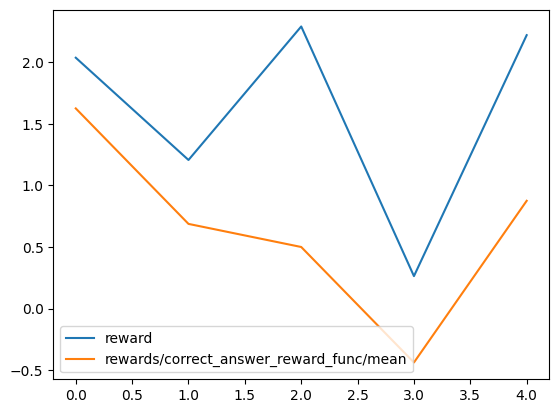

time: 1.57 s (started: 2026-10-07 10:32:34 +00:00)


In [18]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

**Quick train check.** All five reward functions produce non-zero values in the log table (for example, at step 1 the numbering, spelling, counting, formatting and correctness rewards averaged 0.28, -0.75, -0.12, 1.00 and 1.63), so the rewards fire as intended and separate better completions from worse ones. The 5 steps took 1 minute 58 seconds, about 24 seconds per step including start-up, which was used to size the longer run below. As expected, five steps are too few to show a trend in the average reward.

### Slower train (1+ hour)

If everything looks good, let's go for a longer training session!

In [19]:
# Now let's train for real! Let's do a longer training that will take an hour or more
# Note: If this run is successful, you can consider doing a longer train
# to see what happens, but that's beyond the scope of this project.

# Full training
training_args = GRPOConfig(
    **COMMON_GRPO_TRAINING_PARAMS,
    # Configure the maximum number of steps to take about 30mins of time for
    # a medium-sized experiment. (See how long the previous example took and
    # scale up appropriately using your best guess.)
    # The 5-step quick train took 1 min 58 s on the T4 (about 24 s per step,
    # including start-up), so 100 steps is roughly 40 minutes.
    max_steps=100,  # ~40 min on a T4
)
trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=REWARD_FUNCS,
    args=training_args,
    train_dataset=ds,
)
trainer_res = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 401 | Num Epochs = 1 | Total steps = 100
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 1 x 1) = 16
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)



--------------------
Question: How many of the letter "g" are there in the word "glisten"
Answer: 1
Response: <reasoning>
Counting the number of g's in the word glisten
1. g - 1 so far
2. l - 1 so far
3. i - 1 so far
4. t - 1 so far
5. n - 1 so far
6. s - 1 so far
7. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / numbering_reward_func / mean,rewards / numbering_reward_func / std,rewards / spelling_reward_func / mean,rewards / spelling_reward_func / std,rewards / counting_reward_func / mean,rewards / counting_reward_func / std,rewards / format_reward_func / mean,rewards / format_reward_func / std,rewards / correct_answer_reward_func / mean,rewards / correct_answer_reward_func / std
1,0.000000,2.686533,2.757620,88.375000,38.000000,174.000000,0.000000,88.375000,38.000000,174.000000,0.003362,0.398884,0.136867,-0.468750,2.224625,0.131399,0.754631,1.000000,0.000000,1.625000,1.024695
2,0.000000,1.431510,1.997175,78.375000,57.000000,111.000000,0.000000,78.375000,57.000000,111.000000,0.004654,0.430469,0.064545,-1.187500,2.587631,0.126042,0.665656,1.000000,0.000000,1.062500,1.436141
3,0.000000,1.851637,1.337262,88.187500,65.000000,152.000000,0.000000,88.187500,65.000000,152.000000,0.001929,0.466518,0.047264,-0.531250,1.901480,0.791369,0.425933,1.000000,0.000000,0.125000,1.500000
4,0.000000,1.834375,2.206522,79.437500,71.000000,86.000000,0.000000,79.437500,71.000000,86.000000,0.002407,0.473958,0.039893,0.218750,1.940522,0.016667,0.724799,1.000000,0.000000,0.125000,1.500000
5,-0.000000,2.446801,0.869304,77.937500,57.000000,103.000000,0.000000,77.937500,57.000000,103.000000,0.001971,0.478795,0.039780,0.062500,2.351418,0.030506,0.630000,1.000000,0.000000,0.875000,1.500000
6,0.000000,2.167857,2.038398,82.187500,56.000000,107.000000,0.000000,82.187500,56.000000,107.000000,0.003860,0.400446,0.070889,-0.843750,1.814008,0.923661,0.139648,1.000000,0.000000,0.687500,1.537043
7,0.000000,0.546280,2.477982,81.937500,65.000000,102.000000,0.000000,81.937500,65.000000,102.000000,0.006206,0.412946,0.062839,-1.281250,1.612129,0.289583,0.577233,1.000000,0.000000,0.125000,1.500000
8,0.000000,0.376191,1.627870,94.562500,83.000000,122.000000,0.000000,94.562500,83.000000,122.000000,0.006875,0.408780,0.059111,-2.281250,1.852645,0.561161,0.612067,1.000000,0.000000,0.687500,1.537043
9,0.000000,0.799107,3.213084,92.437500,65.000000,127.000000,0.000000,92.437500,65.000000,127.000000,0.012459,0.423363,0.088552,-1.156250,2.399436,0.406994,0.653038,1.000000,0.000000,0.125000,1.500000
10,0.000000,2.155581,1.459810,79.875000,62.000000,98.000000,0.000000,79.875000,62.000000,98.000000,0.018840,0.425223,0.076381,-0.125000,2.004162,0.542857,0.524450,1.000000,0.000000,0.312500,1.537043



--------------------
Question: How many of the letter "e" are there in the word "sapphire"
Answer: 1
Response: <reasoning>
Counting the number of e's in the word sapphire
1. s - 0 so far
2. a - 1 so far
3. p - 1 so far
4. a - 2 so far
5. p - 3 so far
6. h - 3 so far
7. a - 4 so far
8. p - 4 so far
9. y - 4 so far
</reasoning>
<answer>
4
</answer>
Extracted: 4
Correct: False!
    



--------------------
Question: How many of the letter "c" are there in the word "absolve"
Answer: 0
Response: <reasoning>
Counting the number of c's in the word absolve
1. a - 0 so far
2. b - 0 so far
3. c - 1 so far
4. s - 1 so far
5. o - 1 so far
6. v - 1 so far
7. e - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    


...


--------------------
Question: How many of the letter "n" are there in the word "knack"
Answer: 1
Response: <reasoning>
Counting the number of "n"s in the word "knack"
1. k - 0 so far
2. n - 1 so far
3. a - 1 so far
4. c - 1 so far
5. k - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    



--------------------
Question: How many of the letter "p" are there in the word "eclipse"
Answer: 1
Response: <reasoning>
Counting the number of "p"s in the word "eclipse"
1. e - 0 so far
2. p - 1 so far
3. l - 1 so far
4. c - 1 so far
5. i - 1 so far
6. s - 1 so far
7. e - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    



--------------------
Question: How many of the letter "c" are there in the word "capture"
Answer: 1
Response: <reasoning>
Counting the number of "c"s in the word "capture"
1. c - 1 so far
2. a - 1 so far
3. p - 1 so far
4. r - 1 so far
5. e - 1 so far
6. a - 1 so far
7. c - 2 so far
</reasoning>
<answer>
2
</answer>
Extracted: 2
Correct: False!
    



--------------------
Question: How many of the letter "i" are there in the word "gossipy"
Answer: 1
Response: <reasoning>
Counting the number of "i"s in the word "gossipy"
1. g - 0 so far
2. o - 0 so far
3. s - 0 so far
4. s - 0 so far
5. p - 0 so far
6. y - 0 so far
7. y - 1 so far
</reasoning>
<answer>
1
</answer>
Extracted: 1
Correct: True!
    


time: 31min 19s (started: 2026-10-07 10:32:36 +00:00)


available columns: dict_keys(['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/numbering_reward_func/mean', 'rewards/numbering_reward_func/std', 'rewards/spelling_reward_func/mean', 'rewards/spelling_reward_func/std', 'rewards/counting_reward_func/mean', 'rewards/counting_reward_func/std', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/correct_answer_reward_func/mean', 'rewards/correct_answer_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'completion_length', 'kl', 'epoch', 'step'])


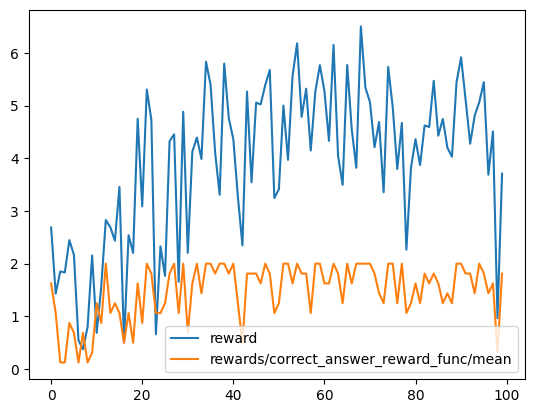

time: 226 ms (started: 2026-10-07 11:03:55 +00:00)


In [20]:
# Show the total (sum) of the rewards as well as the correct_answer_reward_func (means with in the batch)
# Do you see the rewards increasing? Does the model get the correct answer
# more frequently toward the end?
# No changes needed in this cell

import pandas as pd
import matplotlib.pyplot as plt

# If you want to graph other columns, check these out
print(f"available columns: {trainer.state.log_history[0].keys()}")

log_df = pd.DataFrame(trainer.state.log_history)
log_df["reward"].plot()
log_df["rewards/correct_answer_reward_func/mean"].plot()

# Show the legend
plt.legend(["reward", "rewards/correct_answer_reward_func/mean"])
plt.show()

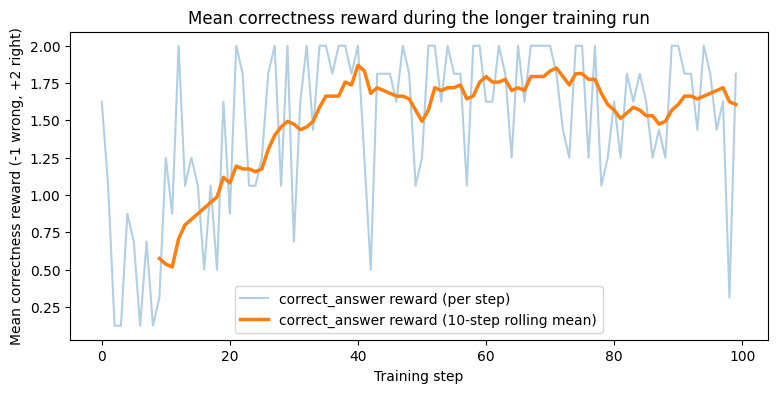

Mean correctness reward, first 20 steps: 0.847
Mean correctness reward, last 20 steps:  1.587
Change: +0.741
Mean total reward, first 20 steps: 1.997, last 20 steps: 4.462
Trend increasing: True
time: 266 ms (started: 2026-10-07 11:03:56 +00:00)


In [21]:
# Smooth the noisy correctness reward with a 10-step rolling average so the
# overall direction of training is easier to judge
corr = log_df["rewards/correct_answer_reward_func/mean"].dropna().reset_index(drop=True)
total = log_df["reward"].dropna().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
corr.plot(ax=ax, alpha=0.35, label="correct_answer reward (per step)")
corr.rolling(10).mean().plot(ax=ax, linewidth=2.5, label="correct_answer reward (10-step rolling mean)")
ax.set_title("Mean correctness reward during the longer training run")
ax.set_xlabel("Training step")
ax.set_ylabel("Mean correctness reward (-1 wrong, +2 right)")
ax.legend()
plt.show()

first_20, last_20 = corr.iloc[:20].mean(), corr.iloc[-20:].mean()
print(f"Mean correctness reward, first 20 steps: {first_20:.3f}")
print(f"Mean correctness reward, last 20 steps:  {last_20:.3f}")
print(f"Change: {last_20 - first_20:+.3f}")
print(f"Mean total reward, first 20 steps: {total.iloc[:20].mean():.3f}, last 20 steps: {total.iloc[-20:].mean():.3f}")
TREND_INCREASING = (last_20 - first_20) > 0.15
print("Trend increasing:", TREND_INCREASING)

### Analysis of the longer training run

**Evidence.** The longer run completed all 100 steps in 31 minutes on the T4. The table and plots above show the mean correctness reward (`rewards/correct_answer_reward_func/mean`, which ranges from -1 when every answer in a batch is wrong to +2 when every answer is right):

| Steps | Mean correctness reward | Mean total reward |
|---|---|---|
| 1 to 25 | 0.95 | 2.24 |
| 26 to 50 | 1.65 | 4.17 |
| 51 to 75 | 1.76 | 4.87 |
| 76 to 100 | 1.57 | 4.35 |

The 10-step rolling mean rises from about 0.85 over the first 20 steps to about 1.59 over the last 20 steps (+0.74), and the total reward more than doubles (from about 2.0 to 4.5). On the 2 / -1 scale, a mean of 1.59 corresponds to roughly 86% of sampled answers being correct, up from roughly 62% at the start.

**What improved.** The component rewards explain where the gain came from. The spelling reward rose from about -0.75 (frequent missing or extra letters) in the first 25 steps to about +0.32 in the last 25, and the counting reward rose from about 0.60 to 0.98, while the formatting reward was already at its maximum of 1.0 throughout because the system prompt specifies the format. In other words, the model mainly learned to spell the word correctly and to keep an accurate running total, which then produced more correct final answers.

**Noise.** Individual steps are noisy (for example step 99 scored 0.31 and step 100 scored 1.81) because each step only sees 4 prompts with 4 generations each, and some words are much harder than others. The curve levels off after about step 50, which suggests that with this learning rate more steps (or a larger batch) would be needed to push accuracy further, but the overall trend across the run is clearly upwards, so no remedial configuration was required.

### Remedial configuration (runs only if the correctness trend is flat)

If the correctness reward did not clearly increase, the cell below changes **one** setting, the learning rate (from 1e-5 to 3e-5), and continues training for a short 25-step run so its effect can be compared with the main run. If the trend is already increasing it is skipped.

In [22]:
if not TREND_INCREASING:
    remedial_args = GRPOConfig(
        **{**COMMON_GRPO_TRAINING_PARAMS, "learning_rate": 3e-5, "output_dir": "outputs_remedial"},
        max_steps=25,
    )
    remedial_trainer = GRPOTrainer(
        model=model,
        processing_class=tokenizer,
        reward_funcs=REWARD_FUNCS,
        args=remedial_args,
        train_dataset=ds.shuffle(seed=7),
    )
    remedial_trainer.train()
    rem_df = pd.DataFrame(remedial_trainer.state.log_history)
    rem_corr = rem_df["rewards/correct_answer_reward_func/mean"].dropna().reset_index(drop=True)
    rem_corr.rolling(5).mean().plot(title="Remedial run: correctness reward (5-step rolling mean)")
    plt.xlabel("Remedial step")
    plt.ylabel("Mean correctness reward")
    plt.show()
    print(f"Remedial run mean correctness reward: {rem_corr.mean():.3f} "
          f"(main run last 20 steps: {last_20:.3f})")
else:
    print("The correctness reward trended upwards in the main run, so no remedial run was needed.")

The correctness reward trended upwards in the main run, so no remedial run was needed.
time: 3.56 ms (started: 2026-10-07 11:03:56 +00:00)


## View the results
Now let's try the model we just trained!

In [23]:
# Save the LoRA adapters
# No changes needed in this cell

# Save the LoRA model
model.save_lora("grpo_saved_lora")

time: 10.7 s (started: 2026-10-07 11:03:56 +00:00)


In [24]:
# Create a function to run both the original model and the updated model
# No changes needed in this cell


def compare_old_and_new_model(messages):
    from vllm import SamplingParams

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    sampling_params = SamplingParams(
        temperature=0.8,
        top_p=0.95,
        max_tokens=1024,
    )
    old = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
        )[0]
        .outputs[0]
        .text
    )

    new = (
        model.fast_generate(
            text,
            sampling_params=sampling_params,
            lora_request=model.load_lora("grpo_saved_lora"),
        )[0]
        .outputs[0]
        .text
    )

    print("===OLD===\n")
    print(old)

    print("\n\n===NEW===\n")
    print(new)


time: 1.4 ms (started: 2026-10-07 11:04:07 +00:00)


### Compare the old and new models on the letter-counting task

In [25]:
# Let's try spelling the first word from the dataset

# Load the first item from the dataset (index 0) and compare the old and new models
compare_old_and_new_model(ds[0]["prompt"])


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests: 100%|██████████| 1/1 [00:00<00:00, 518.90it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it, est. speed input: 52.65 toks/s, output: 32.59 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.99s/it, est. speed input: 52.65 toks/s, output: 32.59 toks/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.07s/it, est. speed input: 34.19 toks/s, output: 21.82 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.07s/it, est. speed input: 34.19 toks/s, output: 21.82 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:03<00:00,  3.07s/it, est. speed input: 34.19 toks/s, output: 21.82 toks/s]

===OLD===

<reasoning>
Counting the number of a's in the word idea
1. i - 1 so far
2. d - 1 so far
3. e - 1 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>


===NEW===

<reasoning>
Counting the number of "a"s in the word "idea"
1. i - 0 so far
2. d - 0 so far
3. e - 0 so far
4. a - 1 so far
</reasoning>
<answer>
1
</answer>
time: 5.09 s (started: 2026-10-07 11:04:07 +00:00)


**Observation on the comparison.** For the first dataset item (how many "a"s are in "idea"), the original model follows the format but its running total is wrong from the first letter (it reports "1 so far" for i, d and e, which are not "a"); it only reaches the right final answer by chance. The fine-tuned model keeps an accurate running total at every step (0, 0, 0, then 1 at the letter "a") and gives the correct answer of 1, which is exactly the step-by-step behaviour the reward functions were designed to encourage. The model was sampled with temperature 0.8, so individual outputs vary from run to run.

Our model is better at spelling and counter letters in words! Depending on your reward functions, the size of your model, and the amount of steps trained, results may vary.

For about an hour of training time, your model may not be perfect (or maybe it is), but it's definitely moving in the right direction!

### Make sure the model did not forget basic facts

In [26]:
# Let's see if the model still remembers some of the facts from its original training

# Ask both the old and new models a question the model is likely to know,
# e.g. a well-known capital city
compare_old_and_new_model(
    [{"role": "user", "content": "What is the capital of the Philippines?"}]
)



Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Adding requests: 100%|██████████| 1/1 [00:00<00:00, 700.45it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s, est. speed input: 95.53 toks/s, output: 23.24 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.58it/s, est. speed input: 95.53 toks/s, output: 23.24 toks/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s, est. speed input: 43.96 toks/s, output: 10.69 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s, est. speed input: 43.96 toks/s, output: 10.69 toks/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s, est. speed input: 43.96 toks/s, output: 10.69 toks/s]

===OLD===

The capital of the Philippines is Manila.


===NEW===

The capital of the Philippines is Manila.
time: 1.25 s (started: 2026-10-07 11:04:12 +00:00)


**Catastrophic forgetting check.** Both the original model and the fine-tuned model answer "The capital of the Philippines is Manila." The LoRA adapter taught the new letter-counting behaviour without erasing the general knowledge of the base model, which is expected because the original 3B weights were frozen and only the small adapter matrices were trained, with a KL penalty (beta) keeping the policy close to the original model.

Great job! Congrats on completing the project! 🎉🤗